In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from mplsoccer import PyPizza, add_image, FontManager
import urllib.request
from utils_foot import create_attacking_indices, create_radar_chart, comprehensive_data_quality_check

### 0. Get data

In [2]:
final_player = pd.read_csv('moneyball/players/final_players_2024.csv')
player_2024=pd.read_csv('moneyball/players/Full_Players_2024.csv')
player_2023=pd.read_csv('moneyball/players/Full_Players_2023.csv')
player_2022=pd.read_csv('moneyball/players/Full_Players_2022.csv')
player_2021=pd.read_csv('moneyball/players/Full_Players_2021.csv')
newbie=pd.read_csv('moneyball/players/newbie_players_2024.csv')
# Fill missing values with 0 in place
final_player.fillna(0, inplace=True)
newbie.fillna(0,inplace=True)
player_2024.fillna(0,inplace=True)
player_2023.fillna(0, inplace=True)
player_2022.fillna(0, inplace=True)
player_2021.fillna(0, inplace=True)

# 1. Complete attacker profile

## 🎯 Objective  
Design a **multidimensional scoring system** that highlights the **most complete attacking players**, going beyond just goal scoring.

---

## 📊 Key Metrics  

### **1. Offensive Contribution Index**  
$$
OCI = (Goals_{/90} \times 0.30) + (xG_{/90} \times 0.15) + (Shot\ Creating\ Actions_{/90} \times 0.20) + (Progressive\ Carries_{/90} \times 0.15) + (Successful\ Take\ Ons_{/90} \times 0.20)
$$

---

### **2. Creativity Score**  
$$
Creativity = Key\ Passes_{/90} + Progressive\ Passes_{/90} + Passes\ into\ Final\ Third_{/90}
$$

---

### **3. Space Generation**  
$$
Space\ Generation = Successful\ Take\ Ons \times Fouls\ Drawn_{/90}
$$

---

## 🔎 Novel Investigations  

- **Player Archetypes**
  - *Clinical Finishers*  
  - *Creative Dribblers*  
  - *Complete Forwards*  

- **Undervalued Attackers**  
  Identify players who consistently **create chances** but **don’t score much**.  

- **Team Success Link**  
  Explore correlation between **progressive carries into the penalty area** and **overall team performance**.  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
import datetime

In [4]:
df=final_player.copy()

1. Check if there are some issues in the dataset

In [5]:
df['Age'] = datetime.datetime.now().year - df['Born'].astype(int)

In [6]:
df_check=df.sort_values(by='Shots_total_per90', ascending=False).head(20)

In [7]:
df_check[['Player', 'Nation', 'Squad', 'Shots_total_per90']].head(5)  # Idl the Shots_total_per90 columns. Values dont seem realistic or Idk what they mean

,Player,Nation,Squad,Shots_total_per90
853,Dango Ouattara,bf BFA,Bournemouth+Bournemouth+Lorient,28.71
899,Morgan Gibbs-White,eng ENG,Nott'ham Forest+Wolves+Nott'ham Forest,27.92
822,Vitinha,pt POR,Genoa+Marseille+Marseille+Paris S-G,22.31
667,Omar Marmoush,eg EGY,Eint Frankfurt+Wolfsburg+Wolfsburg+Stuttgart,16.14
617,Adri Embarba,es ESP,Almería+Almería+Espanyol+Espanyol,13.31


FOOTBALL DATA QUALITY REPORT

1. BASIC OVERVIEW
Total rows: 1496
Total columns: 137
Duplicated rows: 0

2. MISSING DATA ANALYSIS
✅ No missing data found!

3. OUTLIER DETECTION (|Z-Score| > 3)

⚠️  Found outliers in 123 columns:
                             Outlier_Count
Seasons in Serie A                      89
Seasons in PL                           87
Seasons in Bundesliga                   74
Seasons in Ligue 1                      62
Defensive_Goal_per_90                   53
Out_Corner_Kicks_per_90                 47
Corner_Kicks_per_90                     46
In_Corner_Kicks_per_90                  45
Pass_Dead_Shot_per_90                   42
Pass_Dead_Goal_per_90                   42
Second_Yellow_Card_per_90               41
Aerials_Lost_per_90                     41
Penalty_Kicks_Won_per_90                40
Carries_Penalty_Area_per_90             34
Goals_per_shot                          34
Tackled_Take_Ons                        34
Take_Ons_Goal_per_90                    3

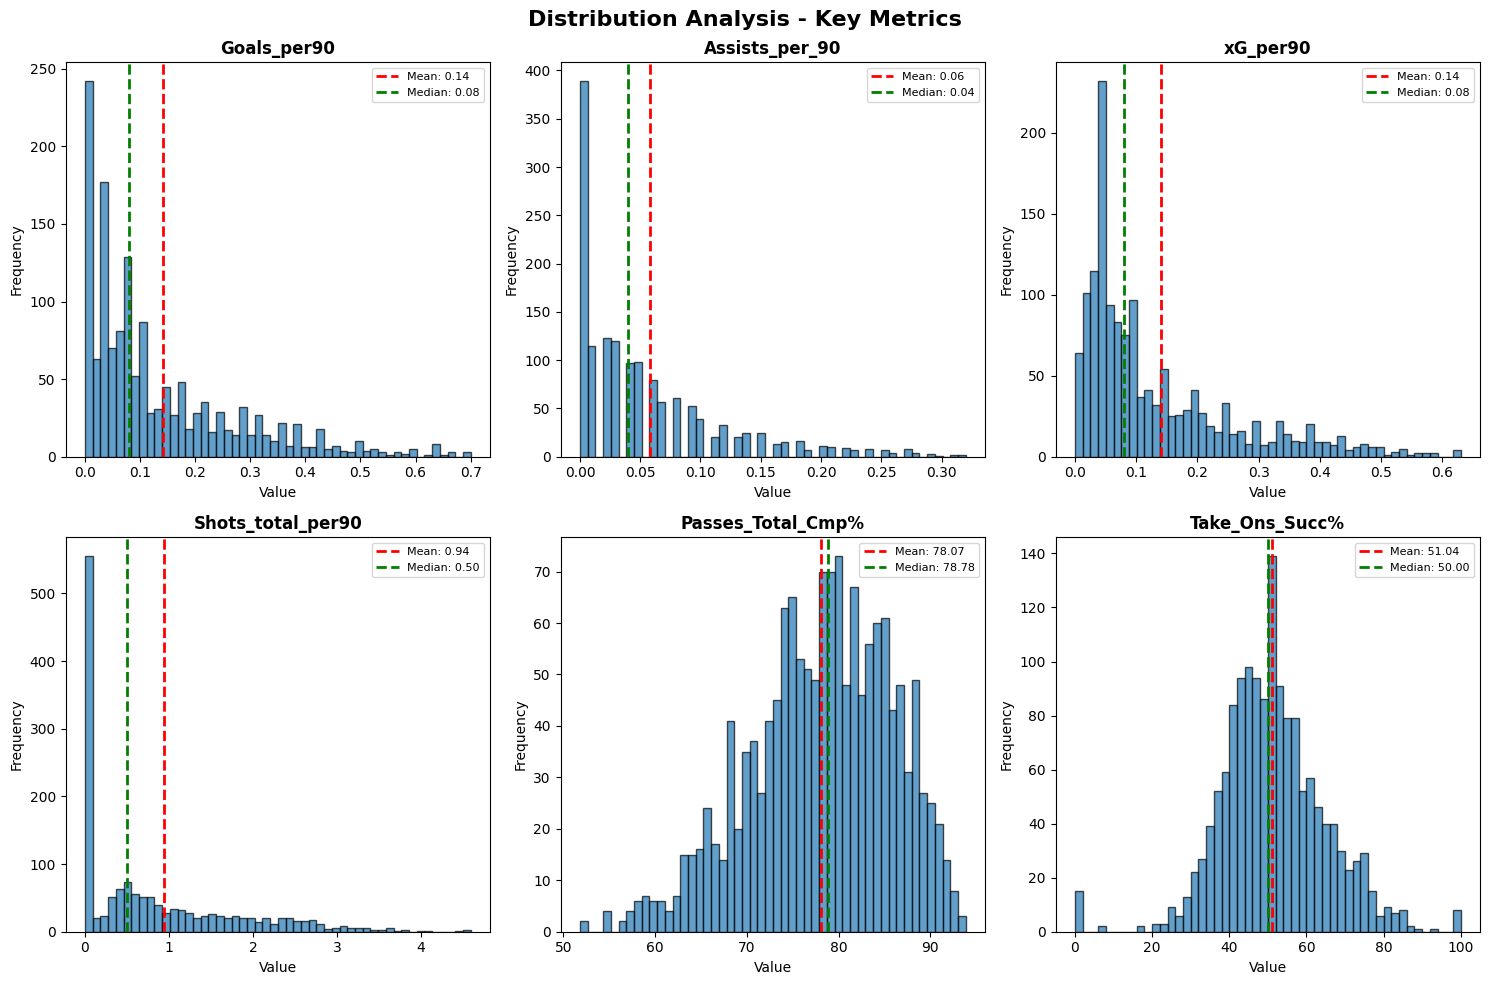


8. CORRELATION SANITY CHECKS
✅ Goals_per90 vs xG_per90: 0.926
⚠️  Weak correlation between Shots_total_per90 and Goals_per90: 0.238 (expected > 0.3)
✅ Passes_Total_Cmp vs Passes_Total_Att: 0.993
✅ Assists_per_90 vs Key_Passes_per_90: 0.482

9. SUMMARY REPORT

Total Issues Found: 126
  - Missing Data: 0 columns
  - Outliers: 123 columns
  - Logical Errors: 3 issues
  - Suspicious Values: 0 columns
  - Data Type Issues: 0 columns

⚠️  Please review the issues above before proceeding with analysis.

10. RECOMMENDATIONS
• Review outliers: Verify if they're legitimate or data errors
• Fix logical inconsistencies before analysis
• Consider filtering players with minimum minutes played (e.g., 900+ minutes)
• Normalize per-90 metrics for fair comparison

DATA QUALITY CHECK COMPLETE!



In [8]:
# Run the comprehensive check
issues = comprehensive_data_quality_check(df)

1.1 Necessary fixes

In [9]:
# FIX 2: Fix invalid percentages (>100 or <0)
percentage_cols = ['Take_Ons_Succ%', 'Dribblers_Tackle_W%', 'Tackled_Take_Ons%', 
                   'Passes_Total_Cmp%', 'Passes_Short_Cmp%', 'Passes_Medium_Cmp%', 'Passes_Long_Cmp%']
for col in percentage_cols:
    if col in df.columns:
        df[col] = df[col].clip(0, 100)

# FIX 3: Fix Goals > Shots issue (set shots to at least equal goals)
if 'Goals_per90' in df.columns and 'Shots_total_per90' in df.columns:
    df.loc[df['Goals_per90'] > df['Shots_total_per90'], 'Shots_total_per90'] = df['Goals_per90']

# FIX 4: Remove extreme outliers in suspicious columns (likely errors)
# Dango Ouattara with 28.71 shots per 90 is clearly wrong
df = df[df['Shots_total_per90'] < 10]  # No one shoots 15+ times per 90 realistically

# FIX 5: Filter minimum minutes for serious analysis
df = df[df['Min'] >= 2000]  # At least 10 full matches

In [10]:
df.shape

(1100, 137)

In [11]:
df.to_csv('reference_data.csv')

2. Create the indices

In [ ]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Total players after filtering: 1108


In [24]:
df_filtered = create_attacking_indices(df)

2.1 Offensive contribution. Surprise results

In [ ]:
top_offensive=df_filtered.sort_values(by='Offensive_Contribution_Index', ascending=False).head(10)[['Player', 'Nation', 'Pos', 'Offensive_Contribution_Index', 
                                                'Goals_per90', 'xG_per90', 'Shot_Creating_Action_per90', 'Progressive_Carries_per_90', 'Take_Ons_Succ_per_90']]

In [46]:
top_offensive

,Player,Nation,Pos,Offensive_Contribution_Index,Goals_per90,xG_per90,Shot_Creating_Action_per90,Progressive_Carries_per_90,Take_Ons_Succ_per_90
155,Gaëtan Laborde,fr FRA,"FW,MF",8.3175,0.42,0.40,38.57,1.81,0.73
148,Romain Faivre,fr FRA,"MF,FW",7.6585,0.27,0.21,31.45,4.88,2.62
329,Francesco Caputo,it ITA,FW,7.1715,0.32,0.35,34.27,0.74,0.29
275,Marc Cucurella,es ESP,DF,7.0980,0.04,0.04,33.15,2.24,0.57
517,Armand Lauriente,fr FRA,FW,7.0735,0.21,0.22,29.44,4.21,2.29
519,Filip Kostić,rs SRB,DF,6.4460,0.10,0.09,28.26,3.99,0.76
255,Amine Gouiri,dz ALG,"FW,MF",6.1030,0.38,0.39,25.94,2.71,1.68
823,Alessandro Zanoli,it ITA,"DF,FW",5.1485,0.07,0.11,22.23,2.86,1.18
599,Emerson Palmieri,it ITA,DF,5.0355,0.04,0.04,22.57,2.29,0.80
207,Lucas Paquetá,br BRA,"FW,MF",4.6905,0.24,0.25,20.07,1.46,1.74


2.2 Creative players. No surprise at all

In [47]:
# Select relevant columns, sort by Creativity_Score descending, and get top 10 players
top_creative_players = (
    df_filtered[['Player', 'Nation', 'Pos', 'Squad', 'Creativity_Score']]
    .sort_values(by='Creativity_Score', ascending=False)
    .head(10)
)

top_creative_players


,Player,Nation,Pos,Squad,Creativity_Score
60,Toni Kroos,de GER,MF,Real Madrid,27.82
94,Joshua Kimmich,de GER,"MF,DF",Bayern Munich,21.95
140,Luis Alberto,es ESP,MF,Lazio,19.98
339,Luka Modrić,hr CRO,MF,Real Madrid,19.53
364,Oleksandr Zinchenko,ua UKR,DF,Arsenal+Manchester City,19.08
195,Rodri,es ESP,MF,Manchester City,19.08
447,Granit Xhaka,ch SUI,MF,Leverkusen+Arsenal,18.68
748,Corentin Tolisso,fr FRA,MF,Lyon,18.50
915,Enzo Fernández,ar ARG,MF,Chelsea,18.48
277,Kevin De Bruyne,be BEL,MF,Manchester City,17.80


2.3 Space generation

In [49]:
top_gen_space_players = (
    df_filtered[['Player', 'Nation', 'Pos', 'Squad', 'Space_Generation']]
    .sort_values(by='Space_Generation', ascending=False)
    .head(10)
)

In [50]:
top_gen_space_players

,Player,Nation,Pos,Squad,Space_Generation
1169,Mohammed Kudus,gh GHA,"FW,MF",West Ham,12.2128
738,Désiré Doué,fr FRA,"MF,FW",Rennes,9.9824
1135,Isco,es ESP,MF,Betis,9.0270
139,Vinicius Júnior,br BRA,FW,Real Madrid,8.9072
62,Mattia Zaccagni,it ITA,"FW,MF",Lazio+Hellas Verona+Lazio+Hellas Verona,8.0290
561,Óscar Trejo,ar ARG,"FW,MF",Rayo Vallecano,7.8960
322,Nabil Fekir,fr FRA,"MF,FW",Betis,7.8186
126,Jack Grealish,eng ENG,"FW,MF",Manchester City+Aston Villa,7.5327
1360,Tiago santos,pt POR,DF,Lille,6.7855
1377,Xavi Simons,nl NED,MF,RB Leipzig,6.7545


2.4 Finishers. Deadly killers

In [51]:
top_finish_quality = (
    df_filtered[['Player', 'Nation', 'Pos', 'Squad', 'Finishing_Quality']]
    .sort_values(by='Finishing_Quality', ascending=False)
    .head(10)
)
top_finish_quality

,Player,Nation,Pos,Squad,Finishing_Quality
1216,Jean-Philippe Mateta,fr FRA,FW,Crystal Palace,0.20
1058,Eren Dinkçi,de GER,"FW,MF",Heidenheim,0.19
54,Phil Foden,eng ENG,"FW,MF",Manchester City,0.18
81,Gianluca Scamacca,it ITA,FW,Atalanta+West Ham+Sassuolo+Genoa,0.18
231,Martin Terrier,fr FRA,"FW,MF",Rennes,0.17
1378,Tim Skarke,de GER,"FW,DF",Darmstadt 98,0.17
963,Leon Bailey,jm JAM,"MF,FW",Aston Villa,0.17
976,Maximilian Beier,de GER,"FW,MF",Hoffenheim,0.17
305,Kylian Mbappé,fr FRA,FW,Paris S-G,0.15
40,Son Heung-min,kr KOR,FW,Tottenham,0.14


2.5 Visualizations

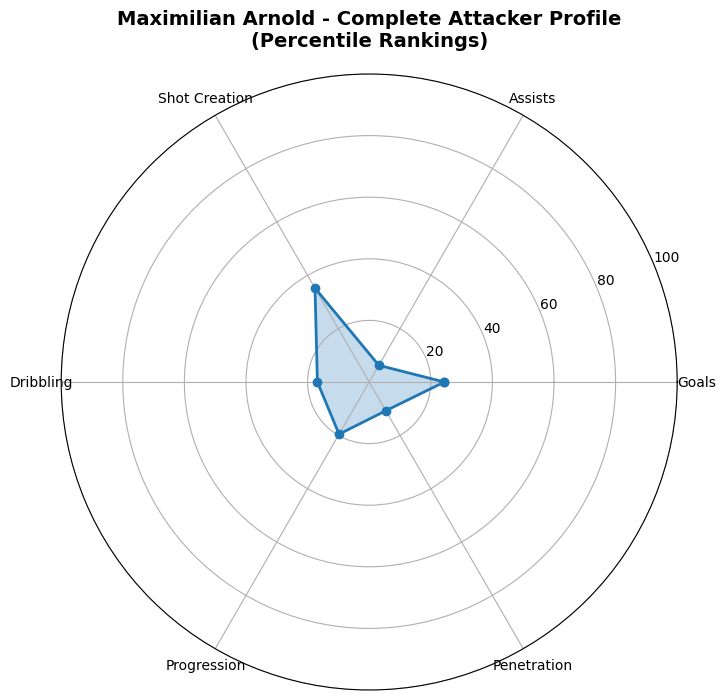

In [74]:
fig = create_radar_chart(df_filtered.iloc[100])

3. Goals prediction

In [79]:
col_tot=df.columns.tolist()
col_tot

['Unnamed: 0',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Comp',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Goals_per90',
 'G+A_per90',
 'G-PK_per90',
 'G+A-PK_per90',
 'xG_per90',
 'xG+xAG_per90',
 'npxG_per90',
 'npxG+xAG_per90',
 'Take_Ons_Attempted',
 'Take_Ons_Succ',
 'Take_Ons_Succ%',
 'Tackled_Take_Ons',
 'Tackled_Take_Ons%',
 'Touches_per_90',
 'Touches_Def_Pen_per_90',
 'Touches_Def_3rd_per_90',
 'Touches_Mid_3rd_per_90',
 'Touches_Att_3rd_per_90',
 'Touches_Att_Pen_per_90',
 'Tocuhes_Live_Balls_per_90',
 'Take_Ons_Attempted_per_90',
 'Take_Ons_Succ_per_90',
 'Tackled_Take_Ons_per_90',
 'Carries_per_90',
 'Total_Distance_per_90',
 'Progressive_Distance_Carried_per_90',
 'Progressive_Carries_per_90',
 '1/3_Carries_per_90',
 'Carries_Penalty_Area_per_90',
 'Miscontrols_per_90',
 'Dispossessed_per_90',
 'Passes_Received_per_90',
 'Progressive_Passes_Received_per_90',
 'Shot_Creating_Action_per90',
 'Goal_Creating_Action_90',
 'Pass_Live_Shot_per_90',
 'Pass_Dead_Shot_per

4. Clustering